In [84]:
import sys
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

E:\My codes\Medical AI\lung-ai-platform


In [85]:
from pathlib import Path
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage import measure

from backend.medical.ct_volume import CTVolume
from backend.medical.preprocessor import CTPreprocessor

In [86]:
dicom_folder = Path(
    r"..\data\raw\lidc_idri\LIDC-IDRI-0001\2000-01-01-30178\3000566-03192"
)

ct = CTVolume(dicom_folder)

preprocessor = CTPreprocessor()

hu_volume = preprocessor.to_hu(ct)

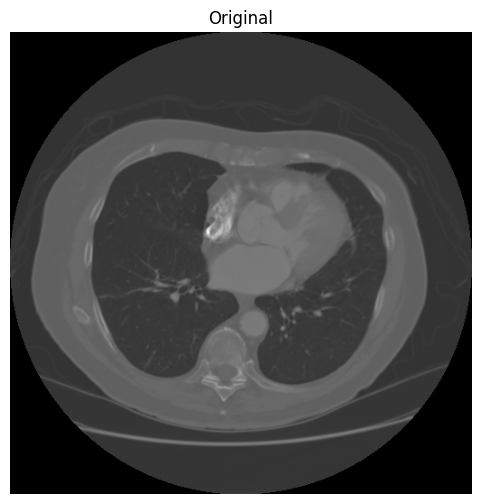

In [87]:
slice_idx = hu_volume.shape[0] // 2

image = hu_volume[slice_idx]

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Original")
plt.show()

In [88]:
body = image > -600

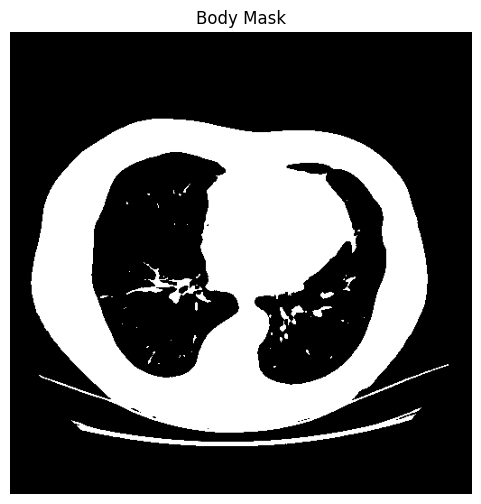

In [89]:
plt.figure(figsize=(6,6))
plt.imshow(body, cmap="gray")
plt.axis("off")
plt.title("Body Mask")
plt.show()

In [90]:
body = ndimage.binary_closing(
    body,
    structure=np.ones((7,7))
)

In [91]:
body = ndimage.binary_fill_holes(body)

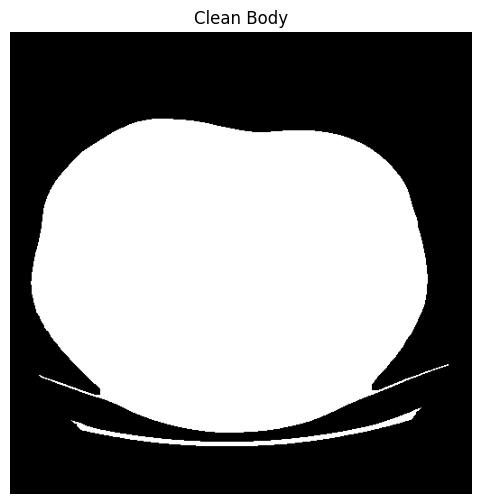

In [92]:
plt.figure(figsize=(6,6))
plt.imshow(body, cmap="gray")
plt.axis("off")
plt.title("Clean Body")
plt.show()

In [93]:
labels = label(body)

regions = regionprops(labels)

largest = max(regions, key=lambda r: r.area)

body_mask = labels == largest.label

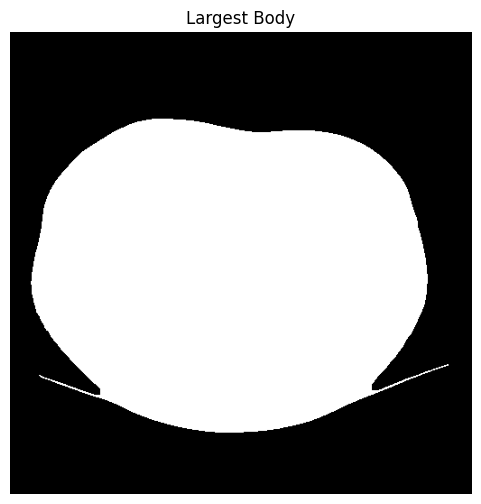

In [94]:
plt.figure(figsize=(6,6))
plt.imshow(body_mask, cmap="gray")
plt.axis("off")
plt.title("Largest Body")
plt.show()

In [95]:
inside_body = image.copy()

inside_body[~body_mask] = 1000

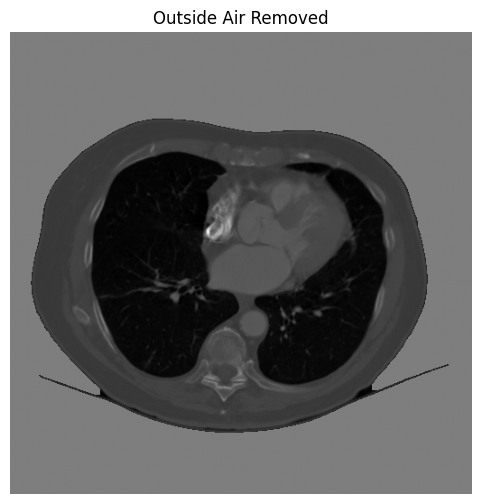

In [96]:
plt.figure(figsize=(6,6))
plt.imshow(inside_body, cmap="gray")
plt.axis("off")
plt.title("Outside Air Removed")
plt.show()

In [97]:
lung = inside_body < -320

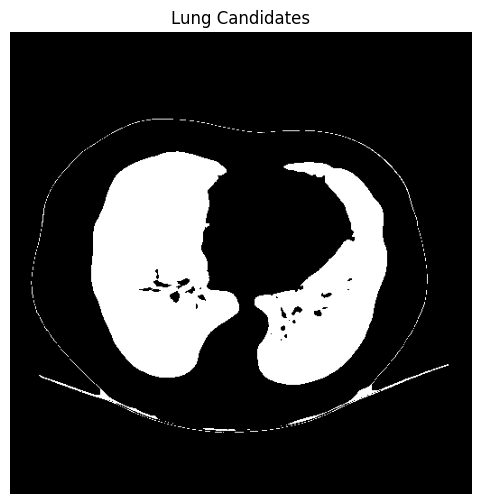

In [98]:
plt.figure(figsize=(6,6))
plt.imshow(lung, cmap="gray")
plt.axis("off")
plt.title("Lung Candidates")
plt.show()

In [99]:
labels = label(lung)

regions = sorted(
    regionprops(labels),
    key=lambda r: r.area,
    reverse=True
)

In [100]:
lung_mask = np.zeros_like(lung)

for region in regions[:2]:
    lung_mask[labels == region.label] = True

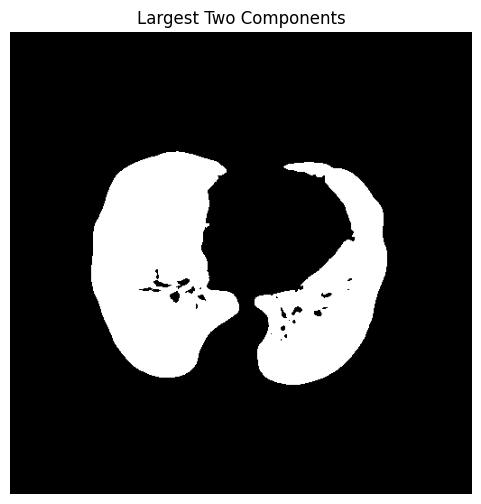

In [101]:
plt.figure(figsize=(6,6))
plt.imshow(lung_mask, cmap="gray")
plt.axis("off")
plt.title("Largest Two Components")
plt.show()

In [102]:
lung_mask = ndimage.binary_opening(
    lung_mask,
    structure=np.ones((3,3))
)

lung_mask = ndimage.binary_closing(
    lung_mask,
    structure=np.ones((5,5))
)

lung_mask = ndimage.binary_fill_holes(
    lung_mask
)

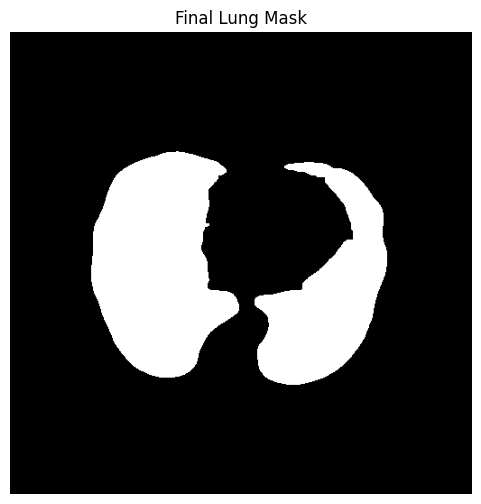

In [103]:
plt.figure(figsize=(6,6))
plt.imshow(lung_mask, cmap="gray")
plt.axis("off")
plt.title("Final Lung Mask")
plt.show()

In [104]:
lung_only = image.copy()

lung_only[~lung_mask] = -1000

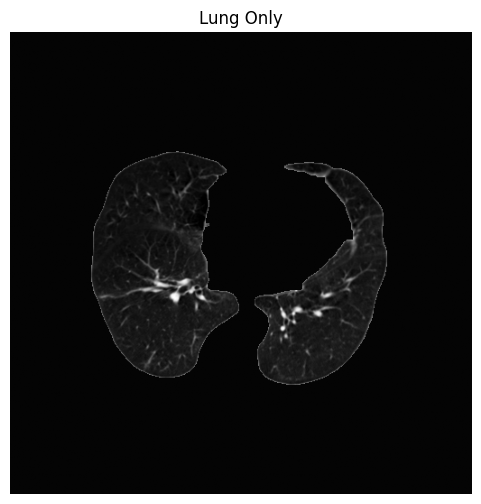

In [105]:
plt.figure(figsize=(6,6))
plt.imshow(lung_only, cmap="gray")
plt.axis("off")
plt.title("Lung Only")
plt.show()

In [106]:
from backend.medical.lung_segmenter import LungSegmenter

segmenter = LungSegmenter()

mask = segmenter.segment_slice(image)

lung = segmenter.apply_mask(
    image,
    mask
)

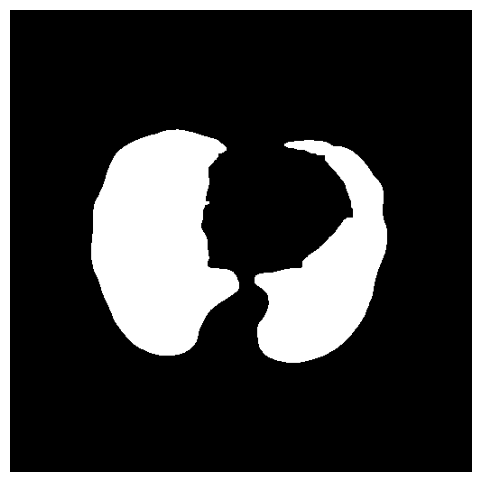

In [107]:
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [108]:
volume_mask = segmenter.segment_volume(
    hu_volume
)